# Gaze Stability Analysis — Excursion Count & Mean Distance
## ATN-DBS Digit Span Backward | Fixation Windows
---

In [1]:
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
warnings.filterwarnings('ignore')

# ═══════════════════════════════════════════════════════════
# PATHS
# ═══════════════════════════════════════════════════════════
SESSION_CONFIG = {
    'Session 2': {
        'json':   Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1433\Report_Json_Session_Report_20260305T151703.json"),
        'csv':    Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-2-Scores.csv"),
        'events': Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\Events.csv"),
        'gaze':   Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-2-GazeData.csv"),
        'out':    Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\GazeAnalysis"),
        'stim_on_trials': [3,7,8,9,10,11,12,13,14],
    },
    'Session 3': {
        'json':   Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1441\Report_Json_Session_Report_20260305T151912.json"),
        'csv':    Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-3-Scores.csv"),
        'events': Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\Preprocessed Data\Events.csv"),
        'gaze':   Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-3-GazeData.csv"),
        'out':    Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\GazeAnalysis"),
        'stim_on_trials': [3,4,7,9],
    },
}

CENTER_X, CENTER_Y = 0.5, 0.5
CENTER_THRESH      = 0.10
EXCURSION_THRESH   = 2        # ≤ this many excursions = stable
DIST_THRESH        = 0.10     # mean dist ≤ this = stable
DISP_THRESH        = 0.04     # SD ≤ this = stable (literature: ~0.03-0.08)

COL_ON       = '#2166AC'
COL_OFF      = '#D6604D'
COL_STABLE   = '#2E7D32'
COL_UNSTABLE = '#C62828'

print('Config loaded.')

Config loaded.


In [2]:
def cohens_d(a, b):
    na, nb = len(a), len(b)
    if na < 2 or nb < 2: return np.nan
    va, vb = np.var(a, ddof=1), np.var(b, ddof=1)
    pooled = np.sqrt(((na-1)*va + (nb-1)*vb) / (na + nb - 2))
    return (np.mean(a) - np.mean(b)) / pooled if pooled > 0 else np.nan

def cohens_h(p1, p2):
    return 2 * (np.arcsin(np.sqrt(p1)) - np.arcsin(np.sqrt(p2)))

def d_label(d):
    if np.isnan(d): return 'N/A'
    ad = abs(d)
    if ad < 0.2: return 'negligible'
    if ad < 0.5: return 'small'
    if ad < 0.8: return 'medium'
    return 'large'

def sig_stars(p):
    if np.isnan(p): return 'n.s.'
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'n.s.'

def safe_sem(arr):
    return stats.sem(arr) if len(arr) > 1 else 0.0

def get_p(a, b, binary=False):
    if binary:
        t = np.array([[int(sum(a)), int(len(a)-sum(a))],
                      [int(sum(b)), int(len(b)-sum(b))]])
        _, p = stats.fisher_exact(t)
    else:
        if len(a) < 2 or len(b) < 2: return np.nan
        _, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    return p

print('Helpers loaded.')

Helpers loaded.


In [3]:
def load_session(cfg, sess_label):
    with open(cfg['json']) as f:
        report = json.load(f)
    df   = pd.read_csv(cfg['csv'],    encoding='utf-8-sig', low_memory=False)
    ev   = pd.read_csv(cfg['events'], encoding='utf-8-sig', low_memory=False)
    gaze = pd.read_csv(cfg['gaze'],   encoding='utf-8-sig', low_memory=False)
    cfg['out'].mkdir(parents=True, exist_ok=True)

    # Gaze XY
    def get_xy(row):
        lv = row['GazePointValidityLeftEye']  == 1
        rv = row['GazePointValidityRightEye'] == 1
        if lv and rv:
            x = (row['GazePointPositionDisplayXLeftEye']  + row['GazePointPositionDisplayXRightEye'])  / 2
            y = (row['GazePointPositionDisplayYLeftEye']  + row['GazePointPositionDisplayYRightEye'])  / 2
        elif lv: x, y = row['GazePointPositionDisplayXLeftEye'],  row['GazePointPositionDisplayYLeftEye']
        elif rv: x, y = row['GazePointPositionDisplayXRightEye'], row['GazePointPositionDisplayYRightEye']
        else:    x, y = np.nan, np.nan
        return x, y
    gaze['gaze_x'], gaze['gaze_y'] = zip(*gaze.apply(get_xy, axis=1))

    def ev_all(etype, tn):
        rows = ev[(ev['Event_Type'] == etype) & (ev['Trial_Number'] == tn)]
        return [float(x) for x in rows['Time_ms'].tolist()]

    stim_on_trials = set(cfg['stim_on_trials'])
    records = []
    for tn in range(1, 20):
        sr = ev[(ev['Event_Type'] == 'Main Trial Start') & (ev['Trial_Number'] == tn)]
        if sr.empty: continue
        r = sr.iloc[0]
        acc   = int(r['ACC']) if pd.notna(r['ACC']) else 0
        n_dig = int(r['Num_Digits']) if pd.notna(r['Num_Digits']) else 0
        stim_starts = ev_all('Stimulus Start', tn)
        stim_ends   = ev_all('Stimulus End',   tn)

        is_stim = tn in stim_on_trials

        for i in range(min(len(stim_starts), len(stim_ends))):
            gw = gaze[(gaze['RTTime'] >= stim_starts[i]) & (gaze['RTTime'] < stim_ends[i])].dropna(subset=['gaze_x','gaze_y'])
            if len(gw) < 3: continue

            xs  = gw['gaze_x'].values
            ys  = gw['gaze_y'].values
            rts = gw['RTTime'].values
            dists = np.sqrt((xs - CENTER_X)**2 + (ys - CENTER_Y)**2)
            outside = dists > CENTER_THRESH

            # --- Metric 1: Excursion count ---
            n_excursions = 0
            was_inside = not outside[0]
            for j in range(1, len(outside)):
                if outside[j] and not outside[j-1]:
                    n_excursions += 1

            # --- Metric 2: Mean distance from center ---
            mean_dist = float(np.mean(dists))

            # --- Metric 3: Gaze dispersion (SD of x,y) ---
            sd_x = float(np.std(xs, ddof=1)) if len(xs) > 1 else 0.0
            sd_y = float(np.std(ys, ddof=1)) if len(ys) > 1 else 0.0
            gaze_sd = np.sqrt(sd_x**2 + sd_y**2)  # combined dispersion

            # --- Metric 3: Refocus time (from first sample) ---
            refocus_ms = np.nan
            for j in range(len(outside)):
                if not outside[j]:
                    if j > 0: refocus_ms = rts[j] - rts[0]
                    break

            records.append({
                'session':       sess_label,
                'trial':         tn,
                'fix_idx':       i + 1,
                'stim':          'ON' if is_stim else 'OFF',
                'acc':           acc,
                'n_digits':      n_dig,
                'n_excursions':  n_excursions,
                'excursion_stable': n_excursions <= EXCURSION_THRESH,
                'mean_dist':     mean_dist,
                'dist_stable':   mean_dist <= DIST_THRESH,
                'inside_prop':   1.0 - np.mean(outside),
                'refocus_ms':    refocus_ms,
                'duration_ms':   rts[-1] - rts[0],
                'sd_x':          sd_x,
                'sd_y':          sd_y,
                'gaze_sd':       gaze_sd,
                'disp_stable':   gaze_sd <= DISP_THRESH,
            })

    rdf = pd.DataFrame(records)
    print(f'  {sess_label}: {len(rdf)} Stimulus windows '
          f'({(rdf["stim"]=="ON").sum()} ON, {(rdf["stim"]=="OFF").sum()} OFF)')
    return rdf

print('Loader ready.')

Loader ready.


In [4]:
all_dfs = []
for sl, cfg in SESSION_CONFIG.items():
    print(f'Loading {sl} ...')
    all_dfs.append(load_session(cfg, sl))
df_all = pd.concat(all_dfs, ignore_index=True)
# Keep only first fixation per trial
df_all = df_all[df_all['fix_idx'] == 1].reset_index(drop=True)
print(f'\nCombined: {len(df_all)} fixation windows')
print('\n--- Excursion counts by stim ---')
print(df_all.groupby('stim')['n_excursions'].describe().round(2))
print('\n--- Mean distance by stim ---')
print(df_all.groupby('stim')['mean_dist'].describe().round(4))

Loading Session 2 ...
  Session 2: 50 Stimulus windows (35 ON, 15 OFF)
Loading Session 3 ...
  Session 3: 40 Stimulus windows (12 ON, 28 OFF)

Combined: 28 fixation windows

--- Excursion counts by stim ---
      count  mean   std  min  25%  50%  75%  max
stim                                            
OFF    15.0  0.53  0.52  0.0  0.0  1.0  1.0  1.0
ON     13.0  1.08  0.95  0.0  0.0  1.0  2.0  3.0

--- Mean distance by stim ---
      count    mean     std     min     25%     50%     75%     max
stim                                                               
OFF    15.0  0.0436  0.0183  0.0213  0.0284  0.0428  0.0535  0.0833
ON     13.0  0.0805  0.0548  0.0142  0.0531  0.0697  0.0842  0.2370


In [5]:
# [REPLACED by plot_continuous_with_threshold — kept for reference]
# def plot_stability_2x2(data, stable_col, method_label, threshold_label, title_prefix, save_path=None):
#     """Generic 2x2 stability plot — clean professional layout."""
#     on  = data[data['stim'] == 'ON']
#     off = data[data['stim'] == 'OFF']
#     on_s  = on[stable_col].astype(int).values
#     off_s = off[stable_col].astype(int).values
# 
#     on_u  = 1 - on_s
#     off_u = 1 - off_s
# 
#     # Stats
#     p_a = get_p(off_s, on_s, binary=True)
#     d_a = cohens_d(off_s, on_s)
#     p_b = p_a
#     d_b = -d_a if not np.isnan(d_a) else np.nan
# 
#     n_on = max(len(on_s), 1)
#     n_on_s, n_on_u = int(on_s.sum()), int(n_on - on_s.sum())
#     p_c = stats.binomtest(n_on_s, len(on_s), 0.5).pvalue if len(on_s) >= 2 else np.nan
#     d_c = cohens_h(n_on_s/n_on, n_on_u/n_on) if (n_on_s > 0 and n_on_u > 0) else np.nan
# 
#     n_off = max(len(off_s), 1)
#     n_off_s, n_off_u = int(off_s.sum()), int(n_off - off_s.sum())
#     p_d = stats.binomtest(n_off_s, len(off_s), 0.5).pvalue if len(off_s) >= 2 else np.nan
#     d_d = cohens_h(n_off_s/n_off, n_off_u/n_off) if (n_off_s > 0 and n_off_u > 0) else np.nan
# 
#     panels = {
#         'A': {'title': 'Stability Rate\nStim OFF vs ON',
#                'labels': ['Stim OFF', 'Stim ON'],
#                'vals': [off_s.mean()*100, on_s.mean()*100],
#                'sems': [safe_sem(off_s)*100, safe_sem(on_s)*100],
#                'ns': [len(off_s), len(on_s)], 'colors': [COL_OFF, COL_ON],
#                'p': p_a, 'd': d_a, 'raw': [off_s, on_s]},
#         'B': {'title': 'Instability Rate\nStim OFF vs ON',
#                'labels': ['Stim OFF', 'Stim ON'],
#                'vals': [off_u.mean()*100, on_u.mean()*100],
#                'sems': [safe_sem(off_u)*100, safe_sem(on_u)*100],
#                'ns': [len(off_u), len(on_u)], 'colors': [COL_OFF, COL_ON],
#                'p': p_b, 'd': d_b, 'raw': [off_u, on_u]},
#         'C': {'title': 'Stim ON\nStable vs Unstable',
#                'labels': ['Stable', 'Unstable'],
#                'vals': [n_on_s/n_on*100, n_on_u/n_on*100],
#                'sems': [0, 0], 'ns': [n_on_s, n_on_u],
#                'colors': [COL_STABLE, COL_UNSTABLE], 'p': p_c, 'd': d_c,
#                'raw': [np.ones(n_on_s), np.zeros(n_on_u)]},
#         'D': {'title': 'Stim OFF\nStable vs Unstable',
#                'labels': ['Stable', 'Unstable'],
#                'vals': [n_off_s/n_off*100, n_off_u/n_off*100],
#                'sems': [0, 0], 'ns': [n_off_s, n_off_u],
#                'colors': [COL_STABLE, COL_UNSTABLE], 'p': p_d, 'd': d_d,
#                'raw': [np.ones(n_off_s), np.zeros(n_off_u)]},
#     }
# 
#     fig, axes = plt.subplots(2, 2, figsize=(13, 11), facecolor='white')
#     fig.suptitle(f'{title_prefix}\n{method_label}  ({threshold_label})',
#                  fontsize=14, fontweight='bold', y=1.02, color='#222')
# 
#     for key, ax in zip(['A','B','C','D'], axes.flat):
#         P = panels[key]
#         xs = np.arange(len(P['labels']))
#         has_sem = max(P['sems']) > 0
#         bar_max = max(P['vals'])
# 
#         # Bars
#         bars = ax.bar(xs, P['vals'], yerr=P['sems'] if has_sem else None,
#                        color=P['colors'], edgecolor='#333', linewidth=1.0,
#                        width=0.50, capsize=5 if has_sem else 0, alpha=0.88,
#                        zorder=3, error_kw={'lw': 1.5, 'capthick': 1.5})
# 
#         # Jittered dots — offset to side of bar, not on top
#         if P.get('raw') is not None:
#             rng = np.random.default_rng(42)
#             for xi, arr in enumerate(P['raw']):
#                 if len(arr):
#                     jitter = rng.uniform(-0.08, 0.08, size=len(arr))
#                     dot_y = arr * 100
#                     # Shift dots slightly right of bar center
#                     ax.scatter(xi + 0.30 + jitter * 0.5, dot_y,
#                                color='#333', s=14, alpha=0.45, zorder=5,
#                                edgecolors='none')
# 
#         # Count labels INSIDE bars (mid-height) to avoid collision
#         for xi, (v, n) in enumerate(zip(P['vals'], P['ns'])):
#             label_y = v / 2 if v > 15 else v + 2
#             va = 'center' if v > 15 else 'bottom'
#             col = 'white' if v > 30 else '#333'
#             ax.text(xi, label_y, f'n={n}\n({v:.1f}%)',
#                     ha='center', va=va, fontsize=9.5, fontweight='bold', color=col)
# 
#         # --- Significance bracket ---
#         p, d = P['p'], P['d']
#         is_sig = not np.isnan(p) and p < 0.05
# 
#         if not np.isnan(p):
#             # Position bracket well above bars
#             y_top = min(bar_max + max(P['sems']) + 8, 95)
#             col_br = '#D32F2F' if is_sig else '#999'
#             lw_br  = 2.0 if is_sig else 1.3
# 
#             ax.plot([0, 0, 1, 1], [y_top, y_top+1.5, y_top+1.5, y_top],
#                     lw=lw_br, color=col_br, zorder=6, clip_on=False)
# 
#             p_str = f'p={p:.4f}' if p >= 0.0001 else 'p<0.0001'
#             d_str = f'd={d:+.2f} ({d_label(d)})' if not np.isnan(d) else ''
#             star  = sig_stars(p)
#             bracket_txt = f'{star}\n{p_str}\n{d_str}' if d_str else f'{star}\n{p_str}'
# 
#             ax.text(0.5, y_top + 2.5, bracket_txt,
#                     ha='center', va='bottom', fontsize=8.5, fontweight='bold',
#                     color=col_br, linespacing=1.1)
# 
#         # Red border if significant
#         if is_sig:
#             for sp in ax.spines.values():
#                 sp.set_edgecolor('#D32F2F'); sp.set_linewidth(2.5)
#         else:
#             for sp in ['top', 'right']:
#                 ax.spines[sp].set_visible(False)
# 
#         ax.set_xticks(xs)
#         ax.set_xticklabels(P['labels'], fontsize=11, fontweight='bold')
#         ax.set_ylabel('Percentage (%)', fontsize=10, color='#444')
#         ax.set_title(P['title'], fontsize=11, fontweight='bold', pad=12, color='#222')
#         ax.set_ylim(0, 108)
#         ax.yaxis.set_major_locator(plt.MultipleLocator(20))
#         ax.grid(True, axis='y', alpha=0.25, color='#ccc', lw=0.8)
#         ax.tick_params(axis='both', labelsize=9, colors='#444')
# 
#     fig.tight_layout(rect=[0, 0, 1, 0.93], h_pad=4.0, w_pad=3.0)
#     if save_path:
#         fig.savefig(str(save_path), dpi=300, bbox_inches='tight', facecolor='white')
#         print(f'  Saved: {save_path}')
#     plt.show(); plt.close(fig)
# 
# print('2x2 plot function ready.')

In [6]:
def plot_continuous_comparison(data, metric_col, metric_label, unit, title_prefix, save_path=None):
    """Bar plot: Stim OFF vs ON for a continuous metric. Clean layout."""
    on_vals  = data[data['stim'] == 'ON'][metric_col].values
    off_vals = data[data['stim'] == 'OFF'][metric_col].values

    means = [np.mean(off_vals) if len(off_vals) else 0,
             np.mean(on_vals)  if len(on_vals) else 0]
    sems  = [safe_sem(off_vals), safe_sem(on_vals)]
    ns    = [len(off_vals), len(on_vals)]

    p = get_p(off_vals, on_vals, binary=False)
    d = cohens_d(off_vals, on_vals)
    is_sig = not np.isnan(p) and p < 0.05
    data_max = max(m + s for m, s in zip(means, sems))

    fig, ax = plt.subplots(figsize=(5.5, 6.5), facecolor='white')
    xs = np.arange(2)
    ax.bar(xs, means, yerr=sems, color=[COL_OFF, COL_ON],
           edgecolor='#333', linewidth=1.0, width=0.50,
           capsize=6, alpha=0.88, zorder=3,
           error_kw={'lw': 1.5, 'capthick': 1.5})

    # Jittered dots — offset to side
    rng = np.random.default_rng(42)
    for xi, arr in enumerate([off_vals, on_vals]):
        if len(arr):
            jitter = rng.uniform(-0.06, 0.06, size=len(arr))
            ax.scatter(xi + 0.30 + jitter * 0.5, arr,
                       color='#333', s=18, alpha=0.45, zorder=5, edgecolors='none')

    # Count labels inside bars
    for xi, (m, s, n) in enumerate(zip(means, sems, ns)):
        fmt = f'{m:.2f}' if m >= 1 else f'{m:.4f}'
        label_y = m / 2 if m > data_max * 0.2 else m + data_max * 0.03
        va = 'center' if m > data_max * 0.2 else 'bottom'
        col = 'white' if m > data_max * 0.35 else '#333'
        ax.text(xi, label_y, f'n={n}\n{fmt} {unit}',
                ha='center', va=va, fontsize=10, fontweight='bold', color=col)

    # Bracket
    y_top = data_max * 1.15
    pad = data_max * 0.02
    col_br = '#D32F2F' if is_sig else '#999'
    lw_br  = 2.0 if is_sig else 1.3
    ax.plot([0, 0, 1, 1], [y_top, y_top+pad, y_top+pad, y_top],
            lw=lw_br, color=col_br, zorder=6, clip_on=False)

    p_str = f'p={p:.4f}' if (not np.isnan(p) and p >= 0.0001) else ('p<0.0001' if not np.isnan(p) else 'p=N/A')
    d_str = f'd={d:+.2f} ({d_label(d)})' if not np.isnan(d) else 'd=N/A'
    ax.text(0.5, y_top + pad * 2, f'{sig_stars(p)}\n{p_str}\n{d_str}',
            ha='center', va='bottom', fontsize=9.5, fontweight='bold',
            color=col_br, linespacing=1.1)

    if is_sig:
        for sp in ax.spines.values():
            sp.set_edgecolor('#D32F2F'); sp.set_linewidth(2.5)
    else:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    ax.set_xticks(xs)
    ax.set_xticklabels(['Stim OFF', 'Stim ON'], fontsize=12, fontweight='bold')
    ax.set_ylabel(f'{metric_label} ({unit})', fontsize=11, fontweight='bold', color='#444')
    ax.set_title(f'{title_prefix}\n{metric_label} — Stim OFF vs ON',
                 fontsize=12, fontweight='bold', pad=14, color='#222')
    ax.set_ylim(0, data_max * 1.45)
    ax.grid(True, axis='y', alpha=0.25, color='#ccc', lw=0.8)
    ax.tick_params(axis='both', labelsize=9, colors='#444')

    fig.tight_layout()
    if save_path:
        fig.savefig(str(save_path), dpi=300, bbox_inches='tight', facecolor='white')
        print(f'  Saved: {save_path}')
    plt.show(); plt.close(fig)

print('Continuous comparison plot ready.')

Continuous comparison plot ready.


## New: Continuous + Threshold Plot Function

Replaces the binary 2×2 stability plots. Encodes stability via threshold line and point colors.

In [7]:
def plot_continuous_with_threshold(data, metric_col, metric_label, unit,
                                    threshold, stable_col,
                                    title_prefix, method_label='', save_path=None):
    """
    Continuous-first gaze stability visualization (redesigned).

    Replaces the binary 2×2 plot with a single publication-quality panel:
    - Bar: mean ± SEM for Stim OFF vs ON
    - Jittered raw data points (colored by stable/unstable)
    - Dashed threshold line encoding the stability criterion
    - Per-condition labels: n, μ, % stable
    - Stats: Mann-Whitney U + Cohen's d only (no binary tests)
    """
    on_data  = data[data['stim'] == 'ON']
    off_data = data[data['stim'] == 'OFF']

    on_vals  = on_data[metric_col].dropna().values
    off_vals = off_data[metric_col].dropna().values

    if len(on_vals) == 0 and len(off_vals) == 0:
        print(f'  {title_prefix}: No data for {metric_col}.')
        return

    means = [np.mean(off_vals) if len(off_vals) else 0,
             np.mean(on_vals)  if len(on_vals) else 0]
    sems  = [safe_sem(off_vals), safe_sem(on_vals)]
    ns    = [len(off_vals), len(on_vals)]

    # % stable per condition (using the binary stable column for labeling only)
    def pct_stable(subset):
        if stable_col and stable_col in subset.columns and len(subset) > 0:
            return subset[stable_col].astype(bool).mean() * 100
        return np.nan

    pct_s_off = pct_stable(off_data)
    pct_s_on  = pct_stable(on_data)

    # Stats — continuous only
    if len(off_vals) >= 2 and len(on_vals) >= 2:
        _, p = stats.mannwhitneyu(off_vals, on_vals, alternative='two-sided')
    else:
        p = np.nan
    d = cohens_d(off_vals, on_vals)
    is_sig = not np.isnan(p) and p < 0.05

    # ── Layout ──────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(6.0, 7.0), facecolor='white')

    xs = np.arange(2)
    ax.bar(xs, means, yerr=sems, color=[COL_OFF, COL_ON],
           edgecolor='#333', linewidth=1.0, width=0.50,
           capsize=6, alpha=0.85, zorder=3,
           error_kw={'lw': 1.5, 'capthick': 1.5})

    # ── Jittered raw points (colored by stable/unstable) ────────────────────
    rng = np.random.default_rng(42)
    for xi, subset in enumerate([off_data, on_data]):
        vals_all = subset[metric_col].dropna().values
        if len(vals_all) == 0:
            continue
        if stable_col and stable_col in subset.columns:
            stable_mask = subset.loc[subset[metric_col].notna(), stable_col].astype(bool).values
        else:
            stable_mask = np.ones(len(vals_all), dtype=bool)

        jitter = rng.uniform(-0.06, 0.06, size=len(vals_all))
        dot_x  = xi + 0.30 + jitter * 0.5

        # Stable points
        if stable_mask.sum() > 0:
            ax.scatter(dot_x[stable_mask], vals_all[stable_mask],
                       color=COL_STABLE, s=26, alpha=0.65, zorder=5,
                       edgecolors='white', linewidths=0.4,
                       label='Stable' if xi == 0 else '_nolegend_')
        # Unstable points
        if (~stable_mask).sum() > 0:
            ax.scatter(dot_x[~stable_mask], vals_all[~stable_mask],
                       color=COL_UNSTABLE, s=26, alpha=0.65, zorder=5,
                       edgecolors='white', linewidths=0.4,
                       label='Unstable' if xi == 0 else '_nolegend_')

    # ── Stability threshold line ─────────────────────────────────────────────
    if threshold is not None:
        ax.axhline(threshold, color='#555555', linestyle='--', linewidth=1.4,
                   zorder=4, alpha=0.75)
        ax.text(1.52, threshold, f'threshold\n({threshold})',
                va='center', ha='left', fontsize=8.5, color='#555555',
                style='italic')

    # ── Per-condition labels ─────────────────────────────────────────────────
    data_max = max((m + s) for m, s in zip(means, sems)) if any(means) else 1
    for xi, (m, s, n, ps) in enumerate(zip(means, sems, ns,
                                           [pct_s_off, pct_s_on])):
        fmt = f'{m:.2f}' if m >= 0.5 else f'{m:.4f}'
        pct_str = f'\n{ps:.0f}% stable' if not np.isnan(ps) else ''
        label_y = m / 2 if m > data_max * 0.25 else m + data_max * 0.03
        va_txt  = 'center' if m > data_max * 0.25 else 'bottom'
        tc      = 'white' if m > data_max * 0.40 else '#222'
        ax.text(xi, label_y,
                f'n={n}\nμ={fmt} {unit}{pct_str}',
                ha='center', va=va_txt,
                fontsize=9.5, fontweight='bold', color=tc)

    # ── Significance bracket ─────────────────────────────────────────────────
    y_top = data_max * 1.18
    pad   = data_max * 0.025
    col_br = '#D32F2F' if is_sig else '#999'
    lw_br  = 2.0 if is_sig else 1.3
    ax.plot([0, 0, 1, 1], [y_top, y_top + pad, y_top + pad, y_top],
            lw=lw_br, color=col_br, zorder=6, clip_on=False)

    p_str = f'p={p:.4f}' if (not np.isnan(p) and p >= 0.0001) else \
            ('p<0.0001' if not np.isnan(p) else 'p=N/A')
    d_str = f'd={d:+.2f} ({d_label(d)})' if not np.isnan(d) else 'd=N/A'
    ax.text(0.5, y_top + pad * 2,
            f'{sig_stars(p)}\n{p_str}\n{d_str}\n(Mann-Whitney U)',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold', color=col_br, linespacing=1.15)

    if is_sig:
        for sp in ax.spines.values():
            sp.set_edgecolor('#D32F2F'); sp.set_linewidth(2.5)
    else:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # ── Legend ───────────────────────────────────────────────────────────────
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles, labels, fontsize=9, framealpha=0.7,
                  loc='upper right', title='Points', title_fontsize=8)

    # ── Axes ─────────────────────────────────────────────────────────────────
    ax.set_xticks(xs)
    ax.set_xticklabels(['Stim OFF', 'Stim ON'], fontsize=12, fontweight='bold')
    ax.set_ylabel(f'{metric_label} ({unit})', fontsize=11, fontweight='bold', color='#444')
    title_parts = [f'{title_prefix}']
    if method_label:
        title_parts.append(method_label)
    title_parts.append(f'{metric_label} — Stim OFF vs ON')
    ax.set_title('\n'.join(title_parts), fontsize=12, fontweight='bold',
                 pad=14, color='#222')
    ax.set_ylim(0, data_max * 1.55)
    ax.grid(True, axis='y', alpha=0.25, color='#ccc', lw=0.8)
    ax.tick_params(axis='both', labelsize=9, colors='#444')

    fig.tight_layout()
    if save_path:
        fig.savefig(str(save_path), dpi=300, bbox_inches='tight', facecolor='white')
        print(f'  Saved: {save_path}')
    plt.show(); plt.close(fig)

print('plot_continuous_with_threshold ready.')


plot_continuous_with_threshold ready.


---
# Section 1: Gaze Stability by Excursion Count

Continuous + threshold visualization (replaces binary 2×2).
- Dashed line = stability threshold (≤2 excursions = stable)
- Green dots = stable trials, Red dots = unstable trials

  Saved: C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\GazeAnalysis\excursion_stability_continuous.png


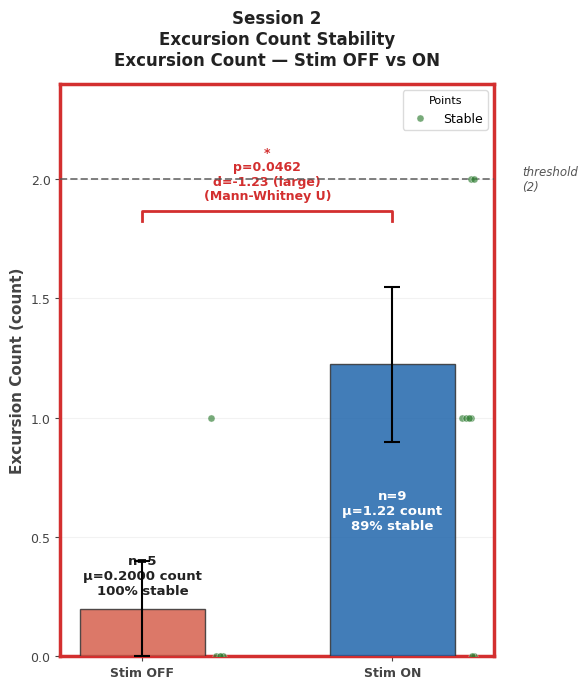

  Saved: C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\GazeAnalysis\excursion_stability_continuous.png


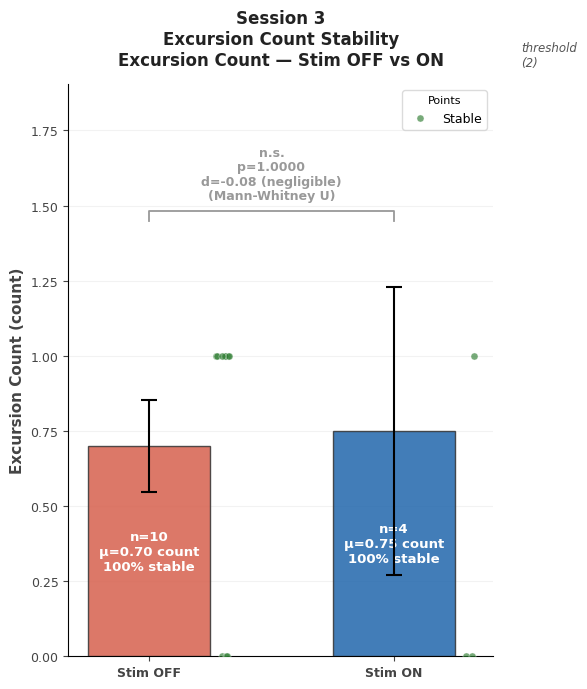

  Saved: C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\excursion_stability_continuous_combined.png


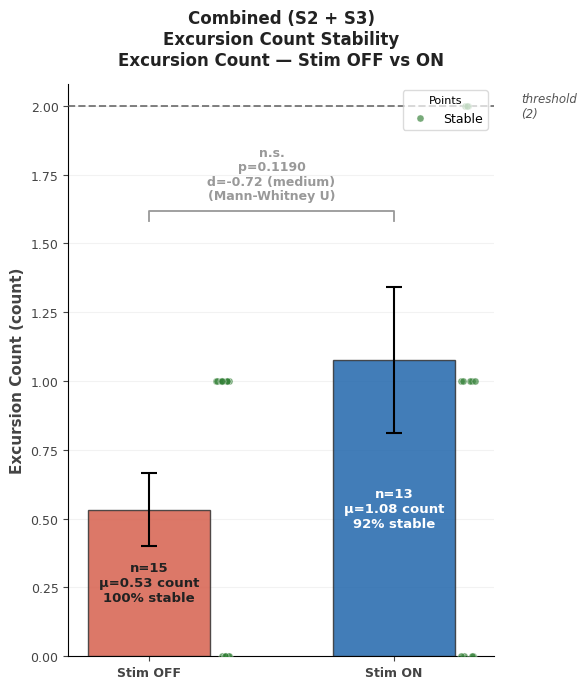

In [8]:
# ═══════════════════════════════════════════════════════════
# SECTION 1A: Excursion Count — Continuous + Threshold Plot
# (Replaces binary 2×2; stability threshold shown as dashed line)
# ═══════════════════════════════════════════════════════════
for sl, cfg in SESSION_CONFIG.items():
    sdf = df_all[df_all['session'] == sl]
    plot_continuous_with_threshold(
        sdf, 'n_excursions', 'Excursion Count', 'count',
        threshold=EXCURSION_THRESH,
        stable_col='excursion_stable',
        method_label='Excursion Count Stability',
        title_prefix=sl,
        save_path=cfg['out'] / 'excursion_stability_continuous.png')

plot_continuous_with_threshold(
    df_all, 'n_excursions', 'Excursion Count', 'count',
    threshold=EXCURSION_THRESH,
    stable_col='excursion_stable',
    method_label='Excursion Count Stability',
    title_prefix='Combined (S2 + S3)',
    save_path=SESSION_CONFIG['Session 2']['out'].parent / 'excursion_stability_continuous_combined.png')


  Saved: C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\GazeAnalysis\excursion_count_continuous.png


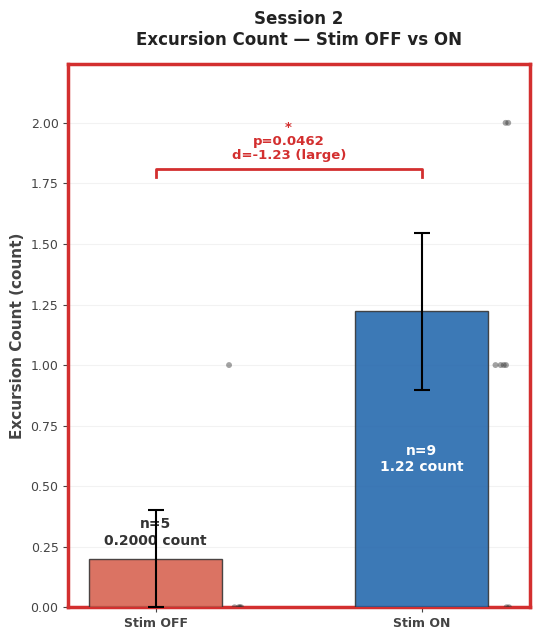

  Saved: C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\GazeAnalysis\excursion_count_continuous.png


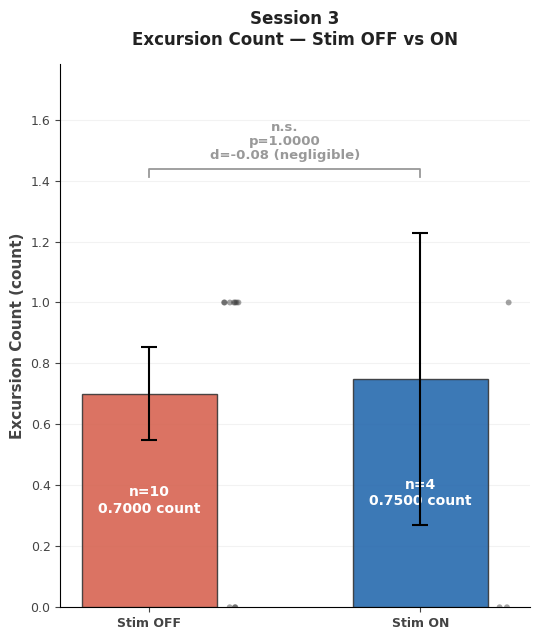

  Saved: C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\excursion_count_continuous_combined.png


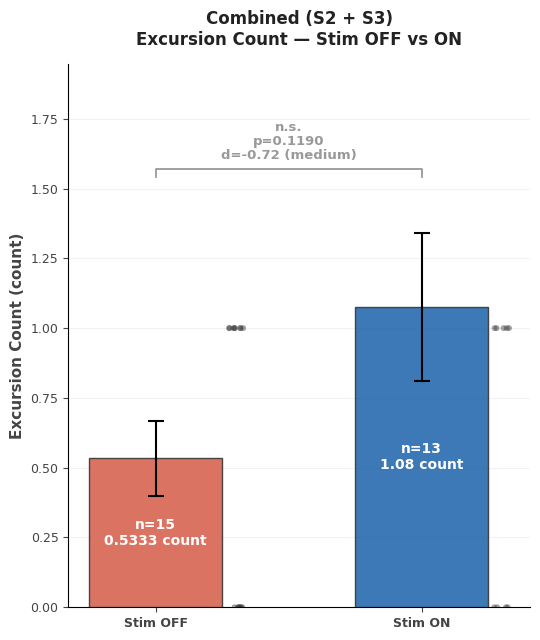

In [9]:
# ═══════════════════════════════════════════════════════════
# SECTION 1B: Excursion Count — Continuous Comparison
# ═══════════════════════════════════════════════════════════
for sl, cfg in SESSION_CONFIG.items():
    sdf = df_all[df_all['session'] == sl]
    plot_continuous_comparison(sdf, 'n_excursions', 'Excursion Count', 'count',
        title_prefix=sl,
        save_path=cfg['out'] / 'excursion_count_continuous.png')

plot_continuous_comparison(df_all, 'n_excursions', 'Excursion Count', 'count',
    title_prefix='Combined (S2 + S3)',
    save_path=SESSION_CONFIG['Session 2']['out'].parent / 'excursion_count_continuous_combined.png')

---
# Section 2: Gaze Stability by Mean Distance from Center

Unstable = mean Euclidean distance from center > 0.10.

**Same 4-panel layout + continuous comparison.**

  Saved: C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\GazeAnalysis\distance_stability_continuous.png


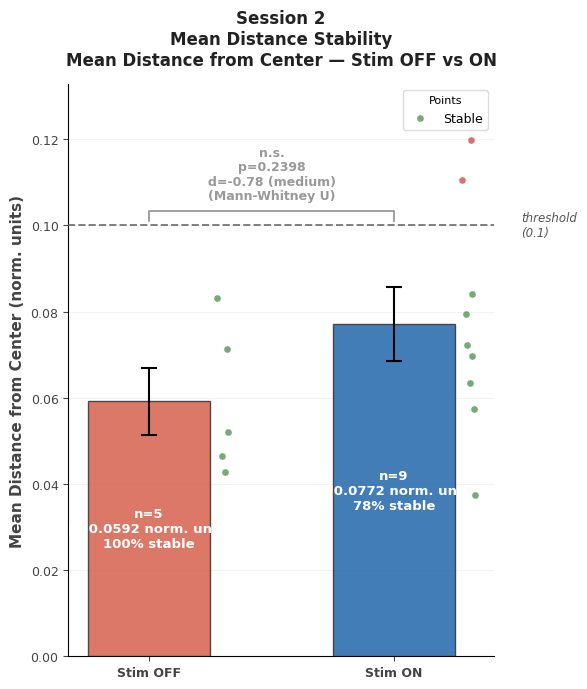

  Saved: C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\GazeAnalysis\distance_stability_continuous.png


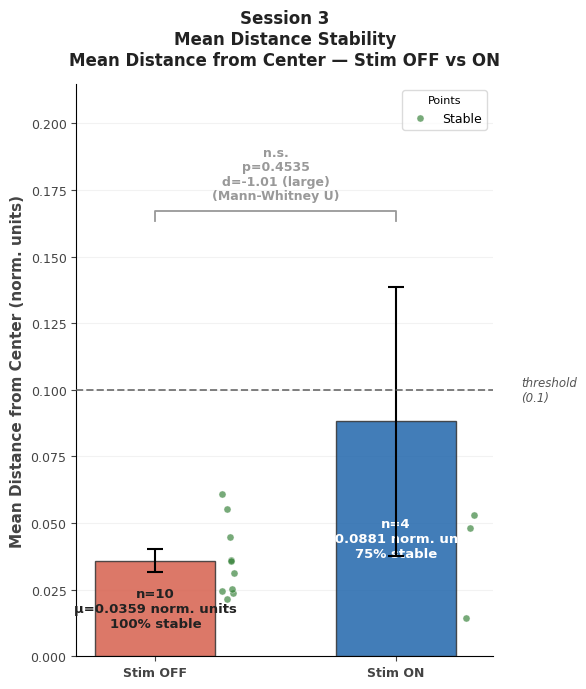

  Saved: C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\distance_stability_continuous_combined.png


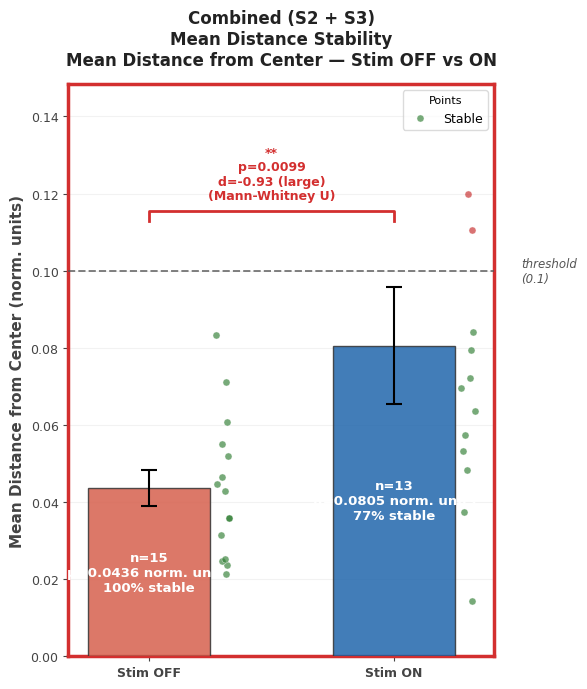

In [10]:
# ═══════════════════════════════════════════════════════════
# SECTION 2A: Mean Distance — Continuous + Threshold Plot
# ═══════════════════════════════════════════════════════════
for sl, cfg in SESSION_CONFIG.items():
    sdf = df_all[df_all['session'] == sl]
    plot_continuous_with_threshold(
        sdf, 'mean_dist', 'Mean Distance from Center', 'norm. units',
        threshold=DIST_THRESH,
        stable_col='dist_stable',
        method_label='Mean Distance Stability',
        title_prefix=sl,
        save_path=cfg['out'] / 'distance_stability_continuous.png')

plot_continuous_with_threshold(
    df_all, 'mean_dist', 'Mean Distance from Center', 'norm. units',
    threshold=DIST_THRESH,
    stable_col='dist_stable',
    method_label='Mean Distance Stability',
    title_prefix='Combined (S2 + S3)',
    save_path=SESSION_CONFIG['Session 2']['out'].parent / 'distance_stability_continuous_combined.png')


  Saved: C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\GazeAnalysis\mean_distance_continuous.png


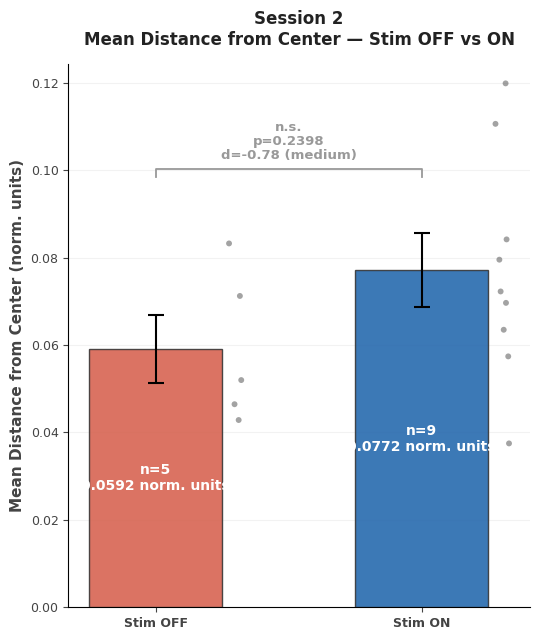

  Saved: C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\GazeAnalysis\mean_distance_continuous.png


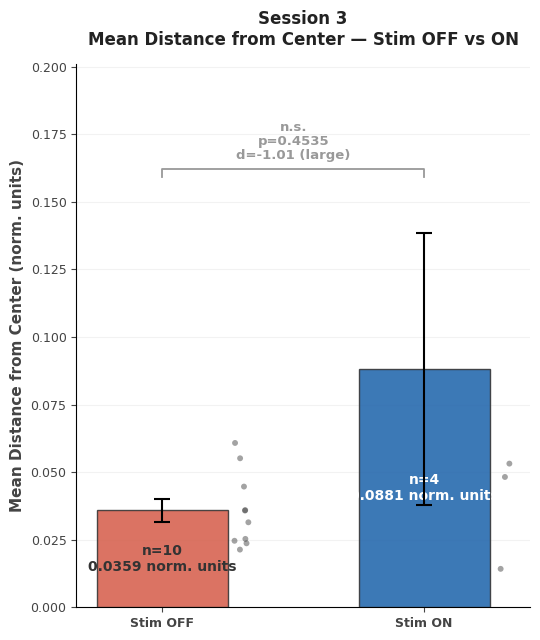

  Saved: C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\mean_distance_continuous_combined.png


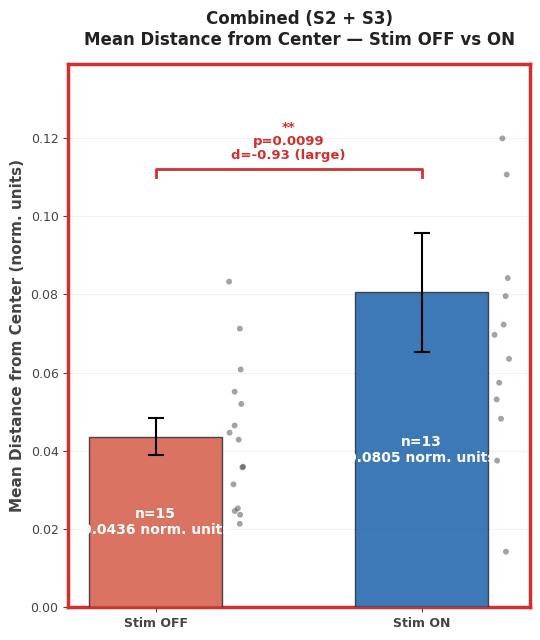

In [11]:
# ═══════════════════════════════════════════════════════════
# SECTION 2B: Mean Distance — Continuous Comparison
# ═══════════════════════════════════════════════════════════
for sl, cfg in SESSION_CONFIG.items():
    sdf = df_all[df_all['session'] == sl]
    plot_continuous_comparison(sdf, 'mean_dist', 'Mean Distance from Center', 'norm. units',
        title_prefix=sl,
        save_path=cfg['out'] / 'mean_distance_continuous.png')

plot_continuous_comparison(df_all, 'mean_dist', 'Mean Distance from Center', 'norm. units',
    title_prefix='Combined (S2 + S3)',
    save_path=SESSION_CONFIG['Session 2']['out'].parent / 'mean_distance_continuous_combined.png')

  Saved: C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\GazeAnalysis\dispersion_stability_continuous.png


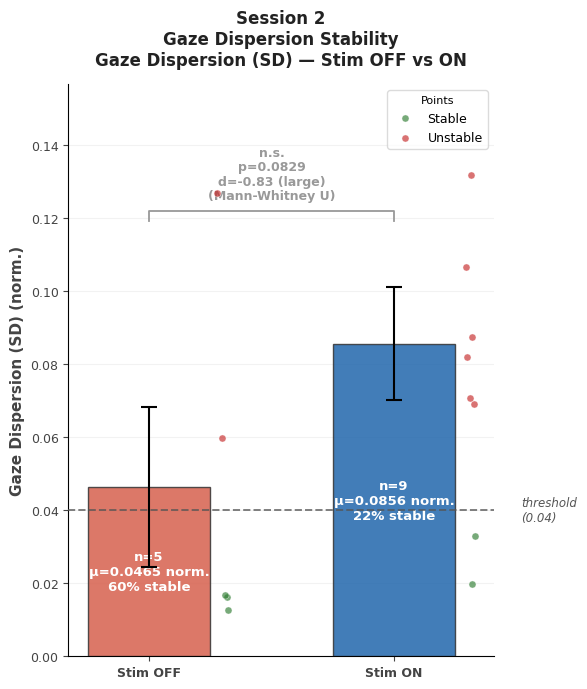

  Saved: C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\GazeAnalysis\dispersion_stability_continuous.png


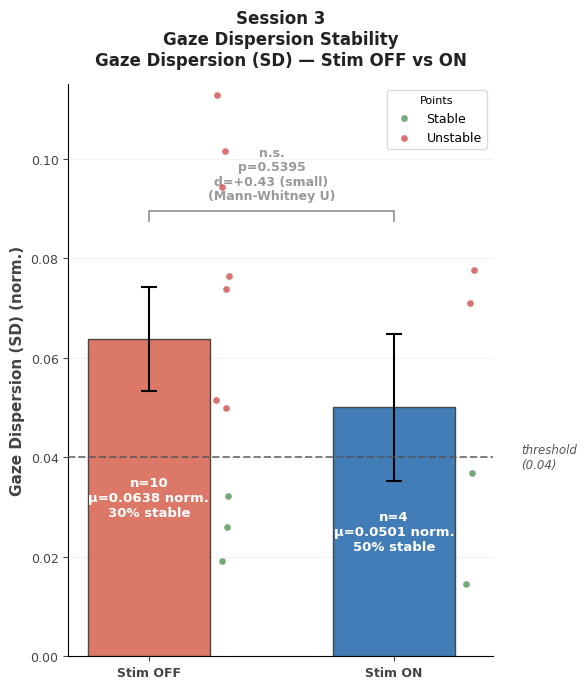

  Saved: C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\dispersion_stability_continuous_combined.png


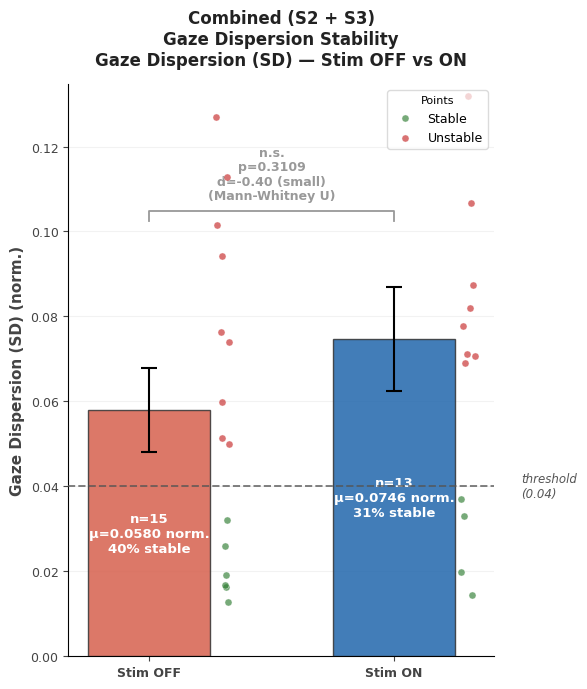

In [12]:
# ═══════════════════════════════════════════════════════════
# SECTION 3A: Gaze Dispersion — Continuous + Threshold Plot
# ═══════════════════════════════════════════════════════════
for sl, cfg in SESSION_CONFIG.items():
    sdf = df_all[df_all['session'] == sl]
    plot_continuous_with_threshold(
        sdf, 'gaze_sd', 'Gaze Dispersion (SD)', 'norm.',
        threshold=DISP_THRESH,
        stable_col='disp_stable',
        method_label='Gaze Dispersion Stability',
        title_prefix=sl,
        save_path=cfg['out'] / 'dispersion_stability_continuous.png')

plot_continuous_with_threshold(
    df_all, 'gaze_sd', 'Gaze Dispersion (SD)', 'norm.',
    threshold=DISP_THRESH,
    stable_col='disp_stable',
    method_label='Gaze Dispersion Stability',
    title_prefix='Combined (S2 + S3)',
    save_path=SESSION_CONFIG['Session 2']['out'].parent / 'dispersion_stability_continuous_combined.png')


  Saved: C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\GazeAnalysis\dispersion_continuous.png


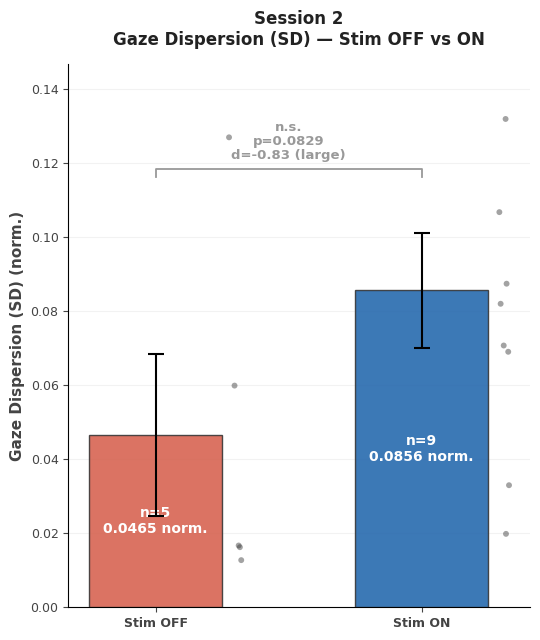

  Saved: C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\GazeAnalysis\dispersion_continuous.png


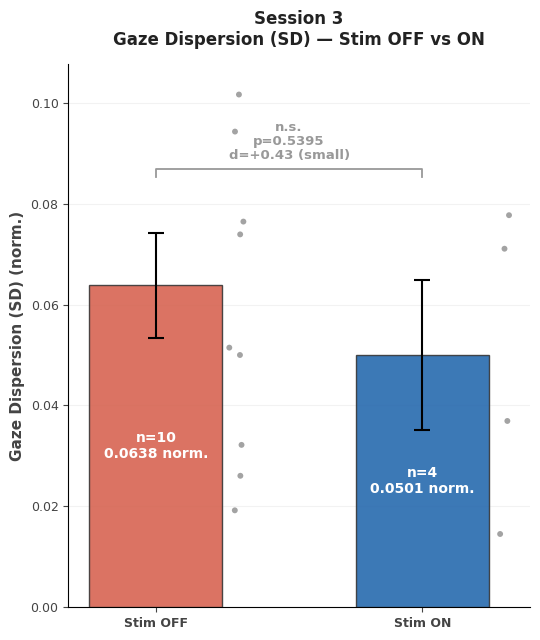

  Saved: C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\dispersion_continuous_combined.png


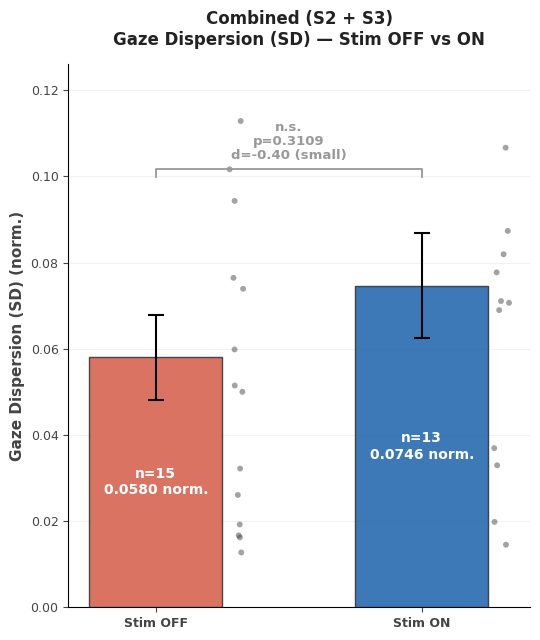

In [13]:
# ═══════════════════════════════════════════════════════════
# SECTION 3B: Gaze Dispersion — Continuous Comparison
# ═══════════════════════════════════════════════════════════
for sl, cfg in SESSION_CONFIG.items():
    sdf = df_all[df_all['session'] == sl]
    plot_continuous_comparison(sdf, 'gaze_sd', 'Gaze Dispersion (SD)', 'norm.',
        title_prefix=sl,
        save_path=cfg['out'] / 'dispersion_continuous.png')

plot_continuous_comparison(df_all, 'gaze_sd', 'Gaze Dispersion (SD)', 'norm.',
    title_prefix='Combined (S2 + S3)',
    save_path=SESSION_CONFIG['Session 2']['out'].parent / 'dispersion_continuous_combined.png')

  Saved: C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\GazeAnalysis\dispersion_components.png


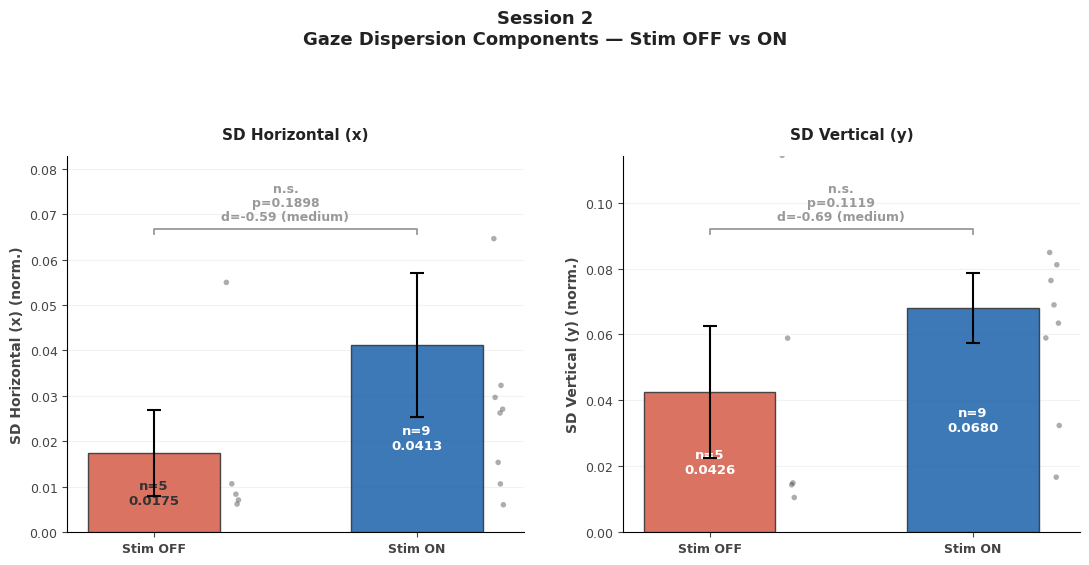

  Saved: C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\GazeAnalysis\dispersion_components.png


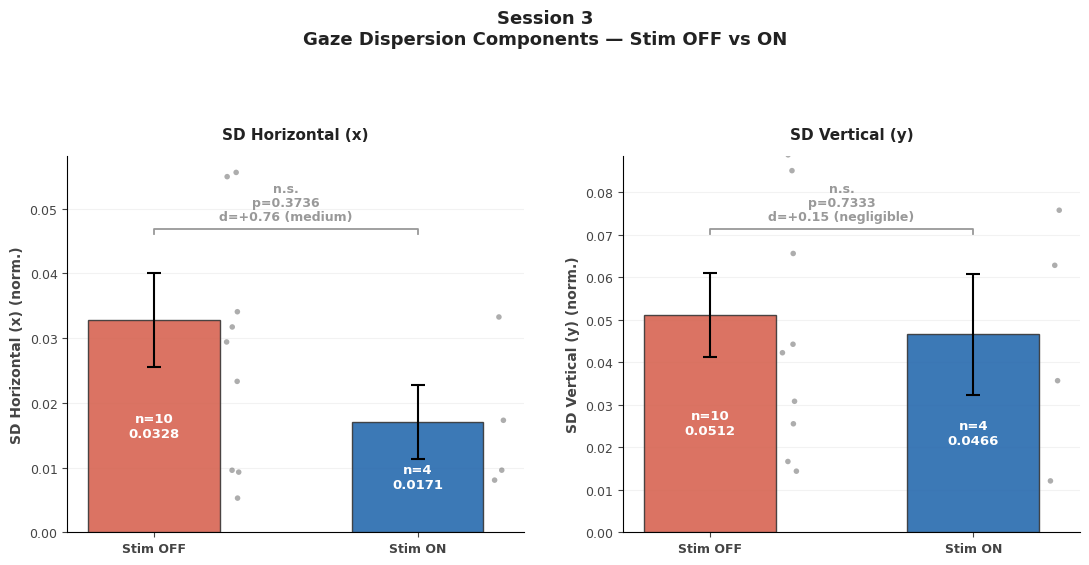

  Saved: C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\dispersion_components_combined.png


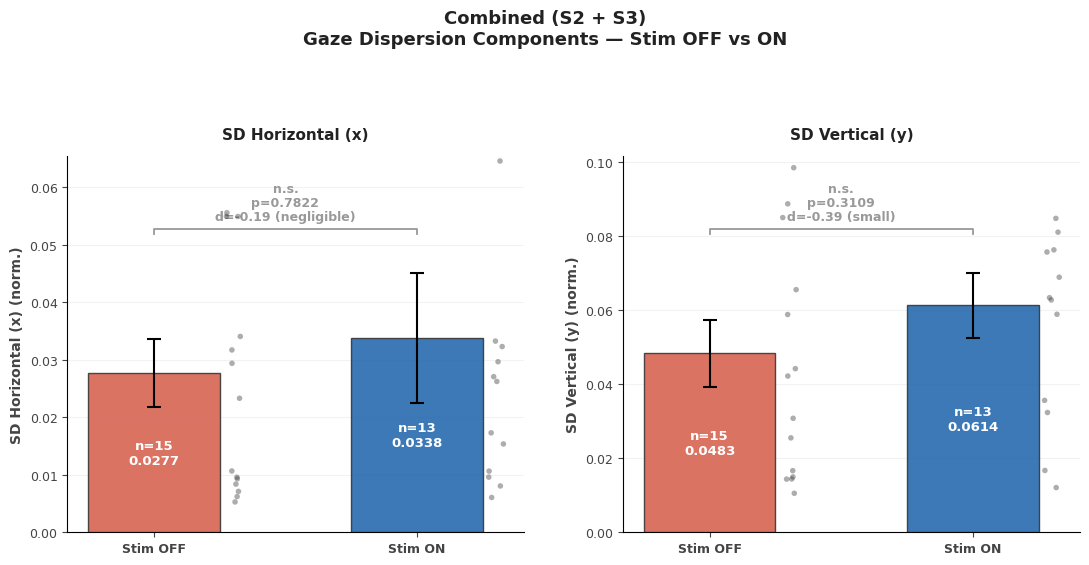

In [14]:
# ═══════════════════════════════════════════════════════════
# SECTION 3C: Component Breakdown — SD_x vs SD_y separately
# ═══════════════════════════════════════════════════════════
def plot_sd_components(data, title_prefix, save_path=None):
    """Side-by-side: SD_x and SD_y, each Stim OFF vs ON."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 5.5), facecolor='white')
    fig.suptitle(f'{title_prefix}\nGaze Dispersion Components — Stim OFF vs ON',
                 fontsize=13, fontweight='bold', y=1.02, color='#222')

    for ax, col, label in zip(axes, ['sd_x', 'sd_y'], ['SD Horizontal (x)', 'SD Vertical (y)']):
        on_v  = data[data['stim']=='ON'][col].values
        off_v = data[data['stim']=='OFF'][col].values
        means = [np.mean(off_v), np.mean(on_v)]
        sems  = [safe_sem(off_v), safe_sem(on_v)]
        ns    = [len(off_v), len(on_v)]
        p = get_p(off_v, on_v, binary=False)
        d = cohens_d(off_v, on_v)
        is_sig = not np.isnan(p) and p < 0.05
        data_max = max(m+s for m,s in zip(means, sems))

        xs = np.arange(2)
        ax.bar(xs, means, yerr=sems, color=[COL_OFF, COL_ON],
               edgecolor='#333', linewidth=1.0, width=0.50,
               capsize=5, alpha=0.88, zorder=3,
               error_kw={'lw': 1.5, 'capthick': 1.5})

        rng = np.random.default_rng(42)
        for xi, arr in enumerate([off_v, on_v]):
            if len(arr):
                jitter = rng.uniform(-0.06, 0.06, size=len(arr))
                ax.scatter(xi + 0.30 + jitter*0.5, arr,
                           color='#333', s=16, alpha=0.4, zorder=5, edgecolors='none')

        for xi, (m, s, n) in enumerate(zip(means, sems, ns)):
            label_y = m/2 if m > data_max*0.2 else m + data_max*0.03
            va = 'center' if m > data_max*0.2 else 'bottom'
            tc = 'white' if m > data_max*0.35 else '#333'
            ax.text(xi, label_y, f'n={n}\n{m:.4f}',
                    ha='center', va=va, fontsize=9.5, fontweight='bold', color=tc)

        y_top = data_max * 1.15
        pad = data_max * 0.02
        col_br = '#D32F2F' if is_sig else '#999'
        ax.plot([0,0,1,1], [y_top, y_top+pad, y_top+pad, y_top],
                lw=2.0 if is_sig else 1.3, color=col_br, zorder=6, clip_on=False)
        p_str = f'p={p:.4f}' if (not np.isnan(p) and p>=0.0001) else ('p<0.0001' if not np.isnan(p) else 'p=N/A')
        d_str = f'd={d:+.2f} ({d_label(d)})' if not np.isnan(d) else 'd=N/A'
        ax.text(0.5, y_top+pad*2, f'{sig_stars(p)}\n{p_str}\n{d_str}',
                ha='center', va='bottom', fontsize=9, fontweight='bold',
                color=col_br, linespacing=1.1)

        if is_sig:
            for sp in ax.spines.values():
                sp.set_edgecolor('#D32F2F'); sp.set_linewidth(2.5)
        else:
            ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

        ax.set_xticks(xs)
        ax.set_xticklabels(['Stim OFF', 'Stim ON'], fontsize=11, fontweight='bold')
        ax.set_ylabel(f'{label} (norm.)', fontsize=10, fontweight='bold', color='#444')
        ax.set_title(label, fontsize=11, fontweight='bold', pad=12, color='#222')
        ax.set_ylim(0, data_max * 1.45)
        ax.grid(True, axis='y', alpha=0.25, color='#ccc', lw=0.8)
        ax.tick_params(axis='both', labelsize=9, colors='#444')

    fig.tight_layout(rect=[0, 0, 1, 0.93], w_pad=3.0)
    if save_path:
        fig.savefig(str(save_path), dpi=300, bbox_inches='tight', facecolor='white')
        print(f'  Saved: {save_path}')
    plt.show(); plt.close(fig)

for sl, cfg in SESSION_CONFIG.items():
    sdf = df_all[df_all['session'] == sl]
    plot_sd_components(sdf, sl,
        save_path=cfg['out'] / 'dispersion_components.png')

plot_sd_components(df_all, 'Combined (S2 + S3)',
    save_path=SESSION_CONFIG['Session 2']['out'].parent / 'dispersion_components_combined.png')

Refocus events: 8 (4 ON, 4 OFF)
  Saved: C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\GazeAnalysis\refocus_first_fixation.png


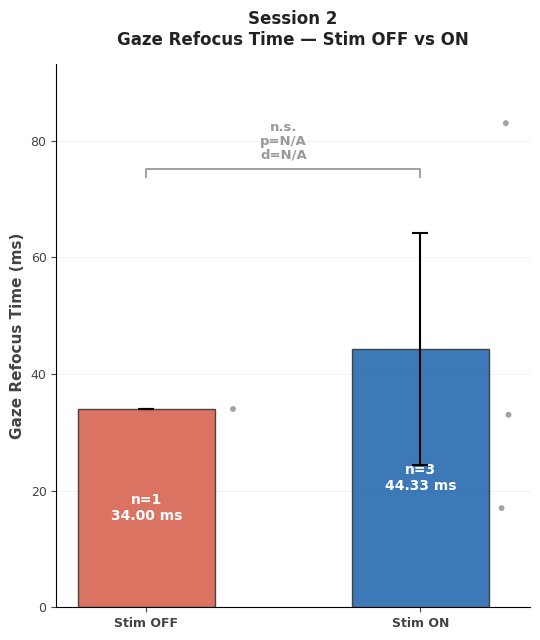

  Saved: C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\GazeAnalysis\refocus_first_fixation.png


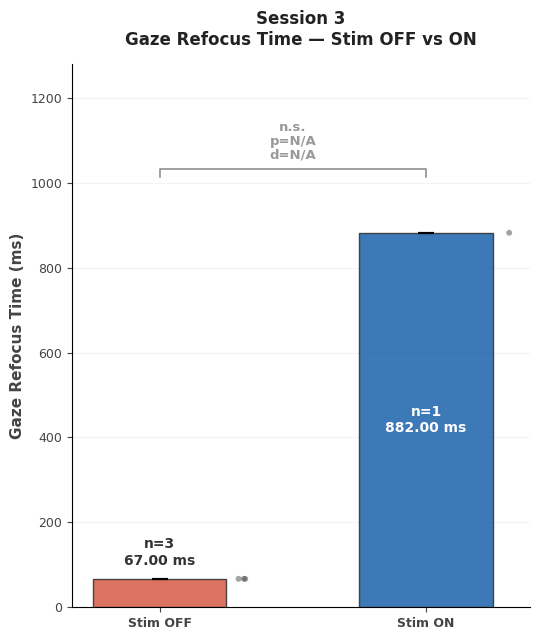

  Saved: C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\refocus_first_fixation_combined.png


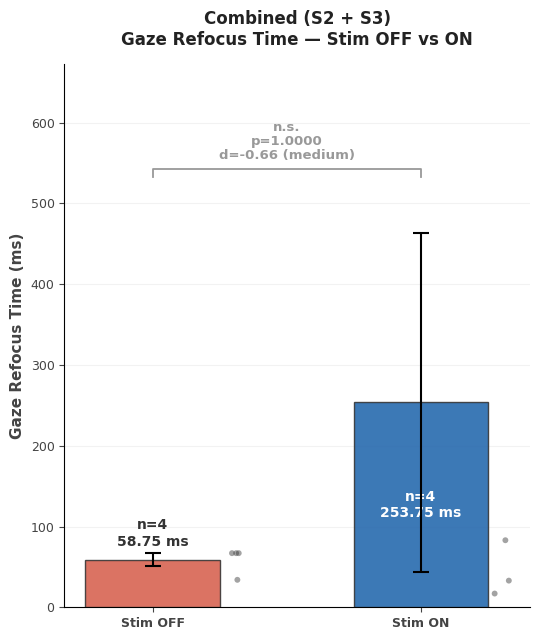

In [15]:
# GAZE REFOCUS — Stim OFF vs ON (first fixation only)
rdf = df_all.dropna(subset=['refocus_ms'])
rdf = rdf[rdf['refocus_ms'] > 0]
print(f'Refocus events: {len(rdf)} ({(rdf["stim"]=="ON").sum()} ON, {(rdf["stim"]=="OFF").sum()} OFF)')

for sl, cfg in SESSION_CONFIG.items():
    sdf = rdf[rdf['session'] == sl]
    if len(sdf):
        plot_continuous_comparison(sdf, 'refocus_ms', 'Gaze Refocus Time', 'ms',
            title_prefix=sl,
            save_path=cfg['out'] / 'refocus_first_fixation.png')

if len(rdf):
    plot_continuous_comparison(rdf, 'refocus_ms', 'Gaze Refocus Time', 'ms',
        title_prefix='Combined (S2 + S3)',
        save_path=SESSION_CONFIG['Session 2']['out'].parent / 'refocus_first_fixation_combined.png')

---
# Summary Statistics Table

All three methods × binary + continuous × S2, S3, Combined.

In [16]:
rows = []
for label, data in [('Session 2', df_all[df_all['session']=='Session 2']),
                     ('Session 3', df_all[df_all['session']=='Session 3']),
                     ('Combined',  df_all)]:
    on  = data[data['stim']=='ON']
    off = data[data['stim']=='OFF']

    # --- Excursion count (binary) ---
    on_eb  = on['excursion_stable'].astype(int).values
    off_eb = off['excursion_stable'].astype(int).values
    p_eb = get_p(off_eb, on_eb, binary=True)
    d_eb = cohens_d(off_eb, on_eb)

    # --- Excursion count (continuous) ---
    on_ec  = on['n_excursions'].values
    off_ec = off['n_excursions'].values
    p_ec = get_p(off_ec, on_ec, binary=False)
    d_ec = cohens_d(off_ec, on_ec)

    # --- Mean distance (binary) ---
    on_db  = on['dist_stable'].astype(int).values
    off_db = off['dist_stable'].astype(int).values
    p_db = get_p(off_db, on_db, binary=True)
    d_db = cohens_d(off_db, on_db)

    # --- Mean distance (continuous) ---
    on_dc  = on['mean_dist'].values
    off_dc = off['mean_dist'].values
    p_dc = get_p(off_dc, on_dc, binary=False)
    d_dc = cohens_d(off_dc, on_dc)

    # --- Gaze dispersion (binary) ---
    on_gb  = on['disp_stable'].astype(int).values
    off_gb = off['disp_stable'].astype(int).values
    p_gb = get_p(off_gb, on_gb, binary=True)
    d_gb = cohens_d(off_gb, on_gb)

    # --- Gaze dispersion (continuous) ---
    on_gc  = on['gaze_sd'].values
    off_gc = off['gaze_sd'].values
    p_gc = get_p(off_gc, on_gc, binary=False)
    d_gc = cohens_d(off_gc, on_gc)

    # --- SD components ---
    p_sx = get_p(off['sd_x'].values, on['sd_x'].values, binary=False)
    d_sx = cohens_d(off['sd_x'].values, on['sd_x'].values)
    p_sy = get_p(off['sd_y'].values, on['sd_y'].values, binary=False)
    d_sy = cohens_d(off['sd_y'].values, on['sd_y'].values)

    rows.append({
        'Dataset': label, 'N_ON': len(on), 'N_OFF': len(off),
        # Excursion binary
        'Exc_Stable%_ON': f'{on_eb.mean()*100:.1f}', 'Exc_Stable%_OFF': f'{off_eb.mean()*100:.1f}',
        'Exc_Bin_p': f'{p_eb:.4f}' if not np.isnan(p_eb) else 'N/A',
        'Exc_Bin_d': f'{d_eb:+.2f}' if not np.isnan(d_eb) else 'N/A', 'Exc_Bin_eff': d_label(d_eb),
        # Excursion continuous
        'Exc_Mean_ON': f'{on_ec.mean():.2f}', 'Exc_Mean_OFF': f'{off_ec.mean():.2f}',
        'Exc_Cont_p': f'{p_ec:.4f}' if not np.isnan(p_ec) else 'N/A',
        'Exc_Cont_d': f'{d_ec:+.2f}' if not np.isnan(d_ec) else 'N/A', 'Exc_Cont_eff': d_label(d_ec),
        # Distance binary
        'Dist_Stable%_ON': f'{on_db.mean()*100:.1f}', 'Dist_Stable%_OFF': f'{off_db.mean()*100:.1f}',
        'Dist_Bin_p': f'{p_db:.4f}' if not np.isnan(p_db) else 'N/A',
        'Dist_Bin_d': f'{d_db:+.2f}' if not np.isnan(d_db) else 'N/A', 'Dist_Bin_eff': d_label(d_db),
        # Distance continuous
        'Dist_Mean_ON': f'{on_dc.mean():.4f}', 'Dist_Mean_OFF': f'{off_dc.mean():.4f}',
        'Dist_Cont_p': f'{p_dc:.4f}' if not np.isnan(p_dc) else 'N/A',
        'Dist_Cont_d': f'{d_dc:+.2f}' if not np.isnan(d_dc) else 'N/A', 'Dist_Cont_eff': d_label(d_dc),
        # Dispersion binary
        'Disp_Stable%_ON': f'{on_gb.mean()*100:.1f}', 'Disp_Stable%_OFF': f'{off_gb.mean()*100:.1f}',
        'Disp_Bin_p': f'{p_gb:.4f}' if not np.isnan(p_gb) else 'N/A',
        'Disp_Bin_d': f'{d_gb:+.2f}' if not np.isnan(d_gb) else 'N/A', 'Disp_Bin_eff': d_label(d_gb),
        # Dispersion continuous
        'Disp_Mean_ON': f'{on_gc.mean():.4f}', 'Disp_Mean_OFF': f'{off_gc.mean():.4f}',
        'Disp_Cont_p': f'{p_gc:.4f}' if not np.isnan(p_gc) else 'N/A',
        'Disp_Cont_d': f'{d_gc:+.2f}' if not np.isnan(d_gc) else 'N/A', 'Disp_Cont_eff': d_label(d_gc),
        # SD components
        'SD_x_ON': f'{on["sd_x"].mean():.4f}', 'SD_x_OFF': f'{off["sd_x"].mean():.4f}',
        'SD_x_p': f'{p_sx:.4f}' if not np.isnan(p_sx) else 'N/A',
        'SD_x_d': f'{d_sx:+.2f}' if not np.isnan(d_sx) else 'N/A',
        'SD_y_ON': f'{on["sd_y"].mean():.4f}', 'SD_y_OFF': f'{off["sd_y"].mean():.4f}',
        'SD_y_p': f'{p_sy:.4f}' if not np.isnan(p_sy) else 'N/A',
        'SD_y_d': f'{d_sy:+.2f}' if not np.isnan(d_sy) else 'N/A',
    })

summary = pd.DataFrame(rows)
display(summary.T)

csv_path = SESSION_CONFIG['Session 2']['out'].parent / 'gaze_all_metrics_summary.csv'
summary.to_csv(csv_path, index=False)
print(f'Saved: {csv_path}')

,0,1,2
Dataset,Session 2,Session 3,Combined
N_ON,9,4,13
N_OFF,5,10,15
Exc_Stable%_ON,88.9,100.0,92.3
Exc_Stable%_OFF,100.0,100.0,100.0
Exc_Bin_p,1.0000,1.0000,0.4643
Exc_Bin_d,+0.41,N/A,+0.41
Exc_Bin_eff,small,N/A,small
Exc_Mean_ON,1.22,0.75,1.08
Exc_Mean_OFF,0.20,0.70,0.53


Saved: C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\gaze_all_metrics_summary.csv
